In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("/content/patient_health_records.xlsx")

In [3]:
df.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P00001,56.0,Female,North,30.208437,147.969376,209.764713,96.536323,1
1,P00002,69.0,Female,East,33.123135,136.648944,NaN,93.466745,1
2,P00003,46.0,Female,West,24.083210,118.614023,156.271168,101.142357,0
3,P00004,32.0,Female,North,27.192960,101.743194,161.220594,105.696506,0
4,P00005,60.0,Male,East,34.278093,105.182540,150.933218,NaN,1


In [4]:
df.isnull().sum()

,0
patient_id,0
age,72
gender,72
region,72
bmi,71
blood_pressure,0
cholesterol,71
glucose,72
disease_risk,0


In [5]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

patient_id        0.000000
age               6.000000
gender            6.000000
region            6.000000
bmi               5.916667
blood_pressure    0.000000
cholesterol       5.916667
glucose           6.000000
disease_risk      0.000000
dtype: float64


In [6]:
missing_report = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})
missing_report

,Missing Values,Percentage
patient_id,0,0.000000
age,72,6.000000
gender,72,6.000000
region,72,6.000000
bmi,71,5.916667
blood_pressure,0,0.000000
cholesterol,71,5.916667
glucose,72,6.000000
disease_risk,0,0.000000


In [7]:
#Mean Imputation
from sklearn.impute import SimpleImputer
mean_imputer = SimpleImputer(strategy="mean")
df["bmi_mean"] = mean_imputer.fit_transform(df[["bmi"]])
df[["bmi","bmi_mean"]].head()

,bmi,bmi_mean
0,30.208437,30.208437
1,33.123135,33.123135
2,24.083210,24.083210
3,27.192960,27.192960
4,34.278093,34.278093


In [8]:
#Median Imputation
median_imputer = SimpleImputer(strategy="median")
df["bmi_median"] = median_imputer.fit_transform(df[["bmi"]])
df[["bmi","bmi_median"]].head()

,bmi,bmi_median
0,30.208437,30.208437
1,33.123135,33.123135
2,24.083210,24.083210
3,27.192960,27.192960
4,34.278093,34.278093


In [9]:
 #Compare Mean vs Median
 print("Original Missing BMI :", df["bmi"].isnull().sum())
print("After Mean Imputation :", df["bmi_mean"].isnull().sum())
print("After Median Imputation :", df["bmi_median"].isnull().sum())

Original Missing BMI : 71
After Mean Imputation : 0
After Median Imputation : 0


In [10]:
cat_imputer = SimpleImputer(strategy="most_frequent")
df["region_imputed"] = cat_imputer.fit_transform(df[["region"]]).ravel()
df[["region","region_imputed"]].head()

,region,region_imputed
0,North,North
1,East,East
2,West,West
3,North,North
4,East,East


In [11]:
gender_imputer = SimpleImputer(strategy="most_frequent")
df["gender_imputed"] = gender_imputer.fit_transform(df[["gender"]]).ravel()
df[["gender","gender_imputed"]].head()

,gender,gender_imputed
0,Female,Female
1,Female,Female
2,Female,Female
3,Female,Female
4,Male,Male


In [12]:
print("Missing Gender Before:", df["gender"].isnull().sum())
print("Missing Gender After:", df["gender_imputed"].isnull().sum())

Missing Gender Before: 72
Missing Gender After: 0


In [13]:
df["bmi_missing"] = df["bmi"].isnull().astype(int)
df[["bmi","bmi_missing"]].head()

,bmi,bmi_missing
0,30.208437,0
1,33.123135,0
2,24.083210,0
3,27.192960,0
4,34.278093,0


In [14]:
df["bmi_random"] = df["bmi"]
random_sample = df["bmi"].dropna().sample(
    df["bmi"].isnull().sum(),
    random_state=42)
random_sample.index = df[df["bmi"].isnull()].index
df.loc[df["bmi"].isnull(), "bmi_random"] = random_sample

In [15]:
print("Missing BMI Before:", df["bmi"].isnull().sum())
print("Missing BMI After:", df["bmi_random"].isnull().sum())

Missing BMI Before: 71
Missing BMI After: 0


In [16]:
from sklearn.impute import KNNImputer
knn_data = df[
    ["age","bmi","blood_pressure",
     "cholesterol","glucose"]]
knn_imputer = KNNImputer(n_neighbors=5)
knn_result = knn_imputer.fit_transform(knn_data)
knn_df = pd.DataFrame(
    knn_result,
    columns=knn_data.columns)
knn_df.head()

,age,bmi,blood_pressure,cholesterol,glucose
0,56.0,30.208437,147.969376,209.764713,96.536323
1,69.0,33.123135,136.648944,203.288444,93.466745
2,46.0,24.083210,118.614023,156.271168,101.142357
3,32.0,27.192960,101.743194,161.220594,105.696506
4,60.0,34.278093,105.182540,150.933218,96.067580


In [17]:
knn_df.isnull().sum()

,0
age,0
bmi,0
blood_pressure,0
cholesterol,0
glucose,0


In [18]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
mice_data = df[
    ["age","bmi",
     "blood_pressure",
     "cholesterol",
     "glucose"]
]
mice_imputer = IterativeImputer(
    random_state=42
)
mice_result = mice_imputer.fit_transform(
    mice_data
)
mice_df = pd.DataFrame(
    mice_result,
    columns=mice_data.columns)
mice_df.head()

,age,bmi,blood_pressure,cholesterol,glucose
0,56.0,30.208437,147.969376,209.764713,96.536323
1,69.0,33.123135,136.648944,203.755745,93.466745
2,46.0,24.083210,118.614023,156.271168,101.142357
3,32.0,27.192960,101.743194,161.220594,105.696506
4,60.0,34.278093,105.182540,150.933218,101.152872


In [19]:
mice_df.isnull().sum()

,0
age,0
bmi,0
blood_pressure,0
cholesterol,0
glucose,0


In [20]:
from scipy.stats import zscore
df["z_score_bmi"] = zscore(df["bmi_median"])
outliers_z = df[
    np.abs(df["z_score_bmi"]) > 3
]
print("Number of Outliers (Z-Score):")
print(len(outliers_z))

Number of Outliers (Z-Score):
9


In [21]:
outliers_z[
    ["bmi_median","z_score_bmi"]
].head()

,bmi_median,z_score_bmi
26,66.069229,6.806382
93,67.535539,7.063487
298,70.805655,7.636875
330,62.025567,6.097359
794,58.736690,5.520682


In [22]:
Q1 = df["bmi_median"].quantile(0.25)
Q3 = df["bmi_median"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers_iqr = df[
    (df["bmi_median"] < lower) |
    (df["bmi_median"] > upper)]
print("Number of Outliers (IQR):")
print(len(outliers_iqr))

Number of Outliers (IQR):
21


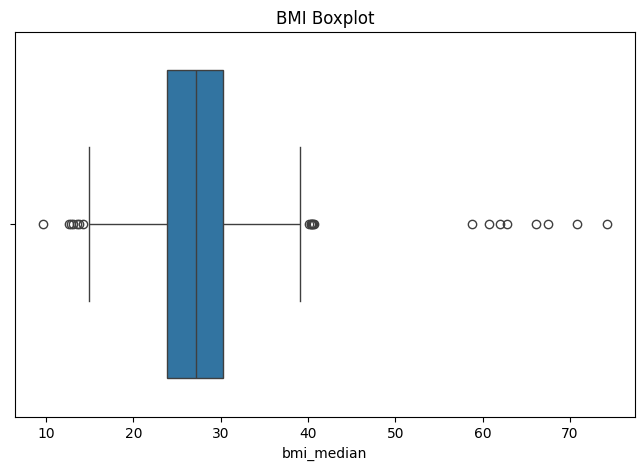

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x=df["bmi_median"])
plt.title("BMI Boxplot")
plt.show()

In [24]:
lower_p = df["bmi_median"].quantile(0.01)
upper_p = df["bmi_median"].quantile(0.99)
outliers_percentile = df[
    (df["bmi_median"] < lower_p) |
    (df["bmi_median"] > upper_p)]
print(
    "Number of Outliers (Percentile):",
    len(outliers_percentile)
)

Number of Outliers (Percentile): 24


In [26]:
from scipy.stats.mstats import winsorize
df["bmi_winsor"] = winsorize(
    df["bmi_median"],
    limits=[0.01, 0.01])
df[[
    "bmi_median",
    "bmi_winsor"
]].head()

,bmi_median,bmi_winsor
0,30.208437,30.208437
1,33.123135,33.123135
2,24.083210,24.083210
3,27.192960,27.192960
4,34.278093,34.278093


In [27]:
print("Original BMI Statistics")
print(df["bmi_median"].describe())
print("\nWinsorized BMI Statistics")
print(df["bmi_winsor"].describe())

Original BMI Statistics
count    1200.000000
mean       27.251415
std         5.705527
min         9.642851
25%        23.874302
50%        27.150808
75%        30.206559
max        74.222077
Name: bmi_median, dtype: float64

Winsorized BMI Statistics
count    1200.000000
mean       27.101923
std         4.828559
min        15.615044
25%        23.874302
50%        27.150808
75%        30.206559
max        40.315912
Name: bmi_winsor, dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


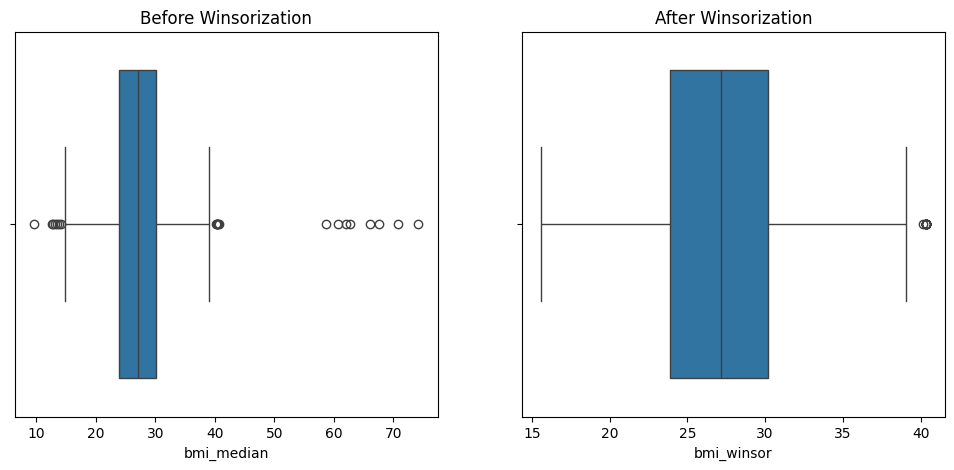

In [28]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(
    x=df["bmi_median"])
plt.title("Before Winsorization")
plt.subplot(1,2,2)
sns.boxplot(
    x=df["bmi_winsor"])
plt.title("After Winsorization")
plt.show()

In [29]:
comparison = pd.DataFrame({
    "Before": df["bmi_median"].describe(),
    "After": df["bmi_winsor"].describe()})
comparison

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


,Before,After
count,1200.000000,1200.000000
mean,27.251415,27.101923
std,5.705527,4.828559
min,9.642851,15.615044
25%,23.874302,23.874302
50%,27.150808,27.150808
75%,30.206559,30.206559
max,74.222077,40.315912


In [30]:
df.to_csv(
    "cleaned_patient_dataset.csv",
    index=False)
print("Dataset Saved Successfully")

Dataset Saved Successfully
